In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn import  linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LassoCV

In [39]:

url = "https://raw.githubusercontent.com/YoanBst/projetDataScienceAbsenteisme/dev/ModelisationPredictive/absences.csv"
data = pd.read_csv(url, encoding='latin1')
data

,intitule_cours,type_cours,groupe_eleve,code_cours,date,date_only,heure,jour_semaine,civilitÃ©,code_eleve,groupes
0,Fondamentaux BD relat.,CMTD,G2,XA1S514C,24/10/2025 08:00,2025-10-24,08:00:00,vendredi,IngÃ© Informatique 3Ã¨me annÃ©e,22302569,"IG3-TP2, IG3-TD2, IG3-TOUS"
1,Projet C,PROJ,G2,XA1S506C,17/11/2025 08:00,2025-11-17,08:00:00,lundi,IngÃ© Informatique 3Ã¨me annÃ©e,22302569,"IG3-TP2, IG3-TD2, IG3-TOUS"
2,Projet C,PROJ,G1,XA1S506C,25/11/2025 08:00,2025-11-25,08:00:00,mardi,IngÃ© Informatique 3Ã¨me annÃ©e,22301636,"IG3-TP1, IG3-TD1, IG3-TOUS"
3,Intro prog C,CMTD,G1,XA1S504C,15/09/2025 14:00,2025-09-15,14:00:00,lundi,IngÃ© Informatique 3Ã¨me annÃ©e,22514917,"IG3-TP1, IG3-TD1, IG3-TOUS"
4,ModÃ©lisation et stat,CMTD,G1,XA1S523C,16/09/2025 14:00,2025-09-16,14:00:00,mardi,IngÃ© Informatique 3Ã¨me annÃ©e,22514917,"IG3-TP1, IG3-TD1, IG3-TOUS"
...,...,...,...,...,...,...,...,...,...,...,...
518,ID Introduction au Droit,CM/CMTD,NaN,XAIG925C,17/10/2025 09:45,2025-10-17,09:45:00,vendredi,IngÃ© Informatique 5Ã¨me annÃ©e,22313692,"IG5-TOUS, IG5-Option 1 - SD"
519,IWA IngÃ©nierie des Applications Web 2,TD,Opt1,XAIG900C,19/11/2025 08:00,2025-11-19,08:00:00,mercredi,IngÃ© Informatique 5Ã¨me annÃ©e,22313692,"IG5-TOUS, IG5-Option 1 - SD"
520,IWA IngÃ©nierie des Applications Web 2,TD,Opt1,XAIG900C,26/11/2025 08:00,2025-11-26,08:00:00,mercredi,IngÃ© Informatique 5Ã¨me annÃ©e,22313692,"IG5-TOUS, IG5-Option 1 - SD"
521,Softskills,CMTD,Opt1,XAIG923C,02/12/2025 14:00,2025-12-02,14:00:00,mardi,IngÃ© Informatique 5Ã¨me annÃ©e,22313692,"IG5-TOUS, IG5-Option 1 - SD"


In [40]:
data['heure'] = data['heure'].astype(str)

# On compte le nombre d'absents par créneau unique (Type + Jour + Heure)
aggregated_data = data.groupby(['type_cours', 'jour_semaine', 'heure']).size().reset_index(name='nombre_absents')

Y = aggregated_data['nombre_absents']

# transformer "Lundi", "Mardi", ..., CM, CMTD, 8h, 9h, ... en chiffres 0/1
X = pd.get_dummies(aggregated_data[['type_cours', 'jour_semaine', 'heure']],
                   drop_first=True)

X = sm.add_constant(X)



--- PREUVE DU SUR-APPRENTISSAGE ---
R² sur le Train     :  0.617
R² sur le Test : -3.161
Différence               : 3.778


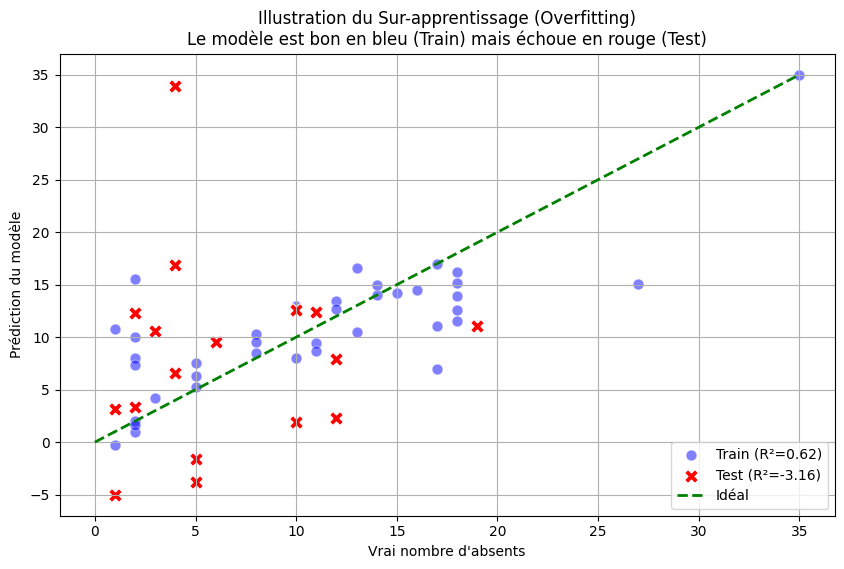

                            OLS Regression Results                            
Dep. Variable:         nombre_absents   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.326
Method:                 Least Squares   F-statistic:                     2.119
Date:                Wed, 14 Jan 2026   Prob (F-statistic):             0.0539
Time:                        10:00:28   Log-Likelihood:                -112.96
No. Observations:                  38   AIC:                             259.9
Df Residuals:                      21   BIC:                             287.8
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -0.31

In [41]:
#Prédiction selon le type et l'heure de début du cours, et le jour de la semaine

# On transforme tout en dummies (plusieurs colonnes : jours, heures, types...)
X = pd.get_dummies(aggregated_data[['type_cours', 'jour_semaine', 'heure']], drop_first=True)
Y = aggregated_data['nombre_absents']
X = sm.add_constant(X)

# SPLIT (Train 70% / Test 30%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)


X_train = X_train.astype(float)
X_test = X_test.astype(float)

# ENTRAÎNEMENT
# OLS nous permet de faire la même chose qu'avec LinearRegression, mais avec un summary() plus détaillé
model_complex = sm.OLS(Y_train, X_train).fit()

# PRÉDICTIONS
y_pred_train = model_complex.predict(X_train)
y_pred_test = model_complex.predict(X_test)


r2_train = model_complex.rsquared
r2_test = r2_score(Y_test, y_pred_test)

# AFFICHAGE DES RÉSULTATS
print("--- PREUVE DU SUR-APPRENTISSAGE ---")
print(f"R² sur le Train     :  {r2_train:.3f}")
print(f"R² sur le Test : {r2_test:.3f}")
print(f"Différence               : {r2_train - r2_test:.3f}")


plt.figure(figsize=(10, 6))

# Points du TRAIN (Bleus)
sns.scatterplot(x=Y_train, y=y_pred_train, color='blue', alpha=0.5, label=f'Train (R²={r2_train:.2f})', s=60)

# Points du TEST (Rouges)
sns.scatterplot(x=Y_test, y=y_pred_test, color='red', marker='X', s=100, label=f'Test (R²={r2_test:.2f})')

# Ligne parfaite
max_val = max(Y.max(), max(y_pred_train.max(), y_pred_test.max()))
plt.plot([0, max_val], [0, max_val], color='green', linestyle='--', linewidth=2, label='Idéal')

plt.title("Illustration du Sur-apprentissage (Overfitting)\nLe modèle est bon en bleu (Train) mais échoue en rouge (Test)")
plt.xlabel("Vrai nombre d'absents")
plt.ylabel("Prédiction du modèle")
plt.legend()
plt.grid(True)
plt.show()


print(model_complex.summary())

In [42]:
# Prédiction selon les deux variables les plus importantes : type_cours_PROJ, et type_cours_CMTD

df_test = aggregated_data.copy()


# On crée une colonne 'type_cours_CMTD' qui vaut 1 si c'est CM OU TD
df_test['type_cours_CMTD'] = (df_test['type_cours'] == 'CMTD').astype(int)

# On crée une colonne 'type_cours_PROJ' qui vaut 1 si c'est un PROJ
df_test['type_cours_PROJ'] = (df_test['type_cours'] == 'PROJ').astype(int)


X = df_test[[ 'type_cours_PROJ', 'type_cours_CMTD']]
Y = df_test['nombre_absents']


X = sm.add_constant(X.astype(float))
Y = Y.astype(float)

model = sm.OLS(Y, X).fit()
y_pred = model.predict(X)


print(model.summary())



                            OLS Regression Results                            
Dep. Variable:         nombre_absents   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     3.438
Date:                Wed, 14 Jan 2026   Prob (F-statistic):             0.0396
Time:                        10:00:28   Log-Likelihood:                -183.07
No. Observations:                  55   AIC:                             372.1
Df Residuals:                      52   BIC:                             378.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               7.6296      1.336     

In [43]:
#Prédiction selon la seule variable ayant une pvalue < 0,05 : type_cours_PROJ

df_test = aggregated_data.copy()


# On crée une colonne 'type_cours_CMTD' qui vaut 1 si c'est CM OU TD
df_test['type_cours_CMTD'] = (df_test['type_cours'] == 'CMTD').astype(int)

# On crée une colonne 'type_cours_PROJ' qui vaut 1 si c'est un PROJ
df_test['type_cours_PROJ'] = (df_test['type_cours'] == 'PROJ').astype(int)


X = df_test[[ 'type_cours_PROJ']]
Y = df_test['nombre_absents']

# Conversion et constante
X = sm.add_constant(X.astype(float))
Y = Y.astype(float)

model= sm.OLS(Y, X).fit()
y_pred = model.predict(X)


print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         nombre_absents   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     4.174
Date:                Wed, 14 Jan 2026   Prob (F-statistic):             0.0460
Time:                        10:00:28   Log-Likelihood:                -184.40
No. Observations:                  55   AIC:                             372.8
Df Residuals:                      53   BIC:                             376.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               9.1321      0.968     

In [44]:
 #Prédiction selon la seconde meilleure variable en terme de pvalue : type_cours_CMTD

df_test = aggregated_data.copy()

df_test['est_CMTD'] = (df_test['type_cours'] == 'CMTD').astype(int)

X = df_test[['est_CMTD']]
Y = df_test['nombre_absents']


X = sm.add_constant(X.astype(float))
Y = Y.astype(float)

# SPLIT (Train 70% / Test 30%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# ENTRAINEMENT
model = sm.OLS(Y_train, X_train).fit()

# PRÉDICTION
y_pred = model.predict(X_test)


r2_train = model.rsquared
r2_test = r2_score(Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))

print(f"R² sur le Train : {r2_train:.4f}")
print(f"R² sur le Test  : {r2_test:.4f}")
print(f"RMSE  : {rmse:.2f} absents")


print("\n--- Détails du modèle (Train) ---")
print(model.summary())



R² sur le Train : 0.0190
R² sur le Test  : -0.7063
RMSE  : 6.32 absents

--- Détails du modèle (Train) ---
                            OLS Regression Results                            
Dep. Variable:         nombre_absents   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                 -0.008
Method:                 Least Squares   F-statistic:                    0.6957
Date:                Wed, 14 Jan 2026   Prob (F-statistic):              0.410
Time:                        10:00:28   Log-Likelihood:                -130.85
No. Observations:                  38   AIC:                             265.7
Df Residuals:                      36   BIC:                             269.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------

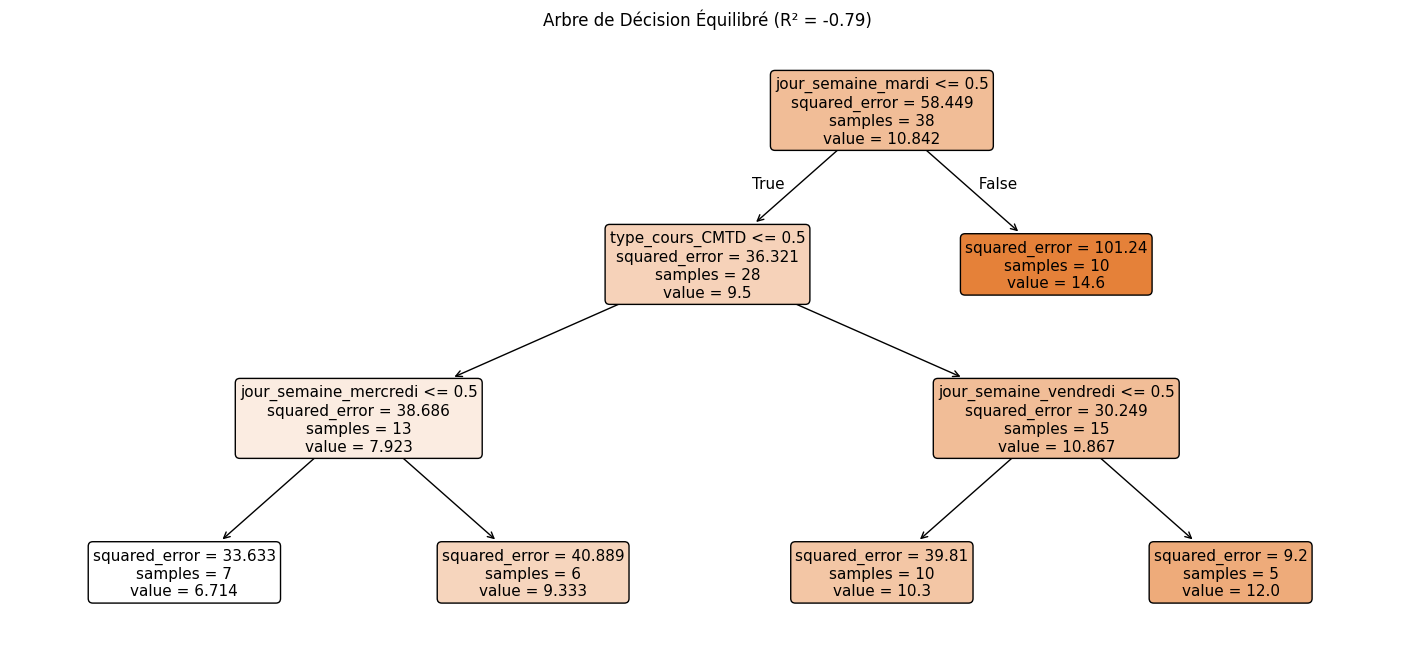

In [45]:


X_tree = pd.get_dummies(aggregated_data[['type_cours', 'jour_semaine', 'heure']], drop_first=True)
Y_tree = aggregated_data['nombre_absents']


# SPLIT (Train 70% / Test 30%)
X_train_t, X_test_t, Y_train_t, Y_test_t = train_test_split(X_tree, Y_tree, test_size=0.3, random_state=42)


# max_depth=3 : On lui laisse 3 étages pour lisser les anomalies
# min_samples_leaf=5 : impose qu'une règle décisionnelle s'appuie sur un minimum de 5 observations pour être validée
tree_reg_balanced = DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=42)
tree_reg_balanced.fit(X_train_t, Y_train_t)


r2 = tree_reg_balanced.score(X_test_t, Y_test_t)

plt.figure(figsize=(18, 8), dpi=100)
_ = plot_tree(tree_reg_balanced,
              feature_names=X_train_t.columns.tolist(),
              filled=True,
              rounded=True,
              fontsize=11)

plt.title(f"Arbre de Décision Équilibré (R² = {r2:.2f})")
plt.show()

R² du Lasso : 0.145
Alpha (Pénalité) retenu : 0.3491


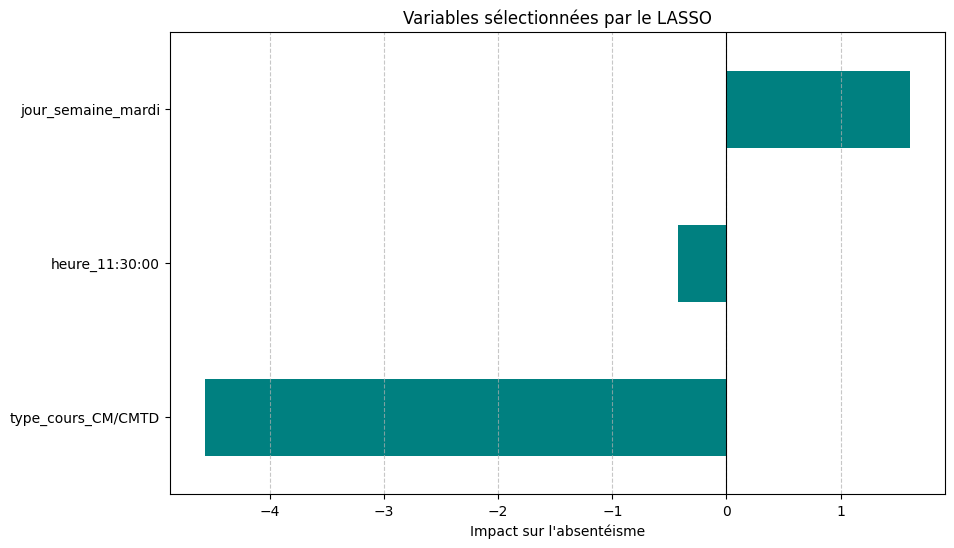


--- CONCLUSION DU LASSO ---
Variables conservées (Coefficient non nul) :
type_cours_CM/CMTD   -4.565742
jour_semaine_mardi    1.605128
heure_11:30:00       -0.422884
dtype: float64


In [46]:


X_lasso = pd.get_dummies(aggregated_data[['type_cours', 'jour_semaine', 'heure']], drop_first=True)
Y_lasso = aggregated_data['nombre_absents']


# SPLIT (Train 70% / Test 30%)
X_train_t, X_test_t, Y_train_t, Y_test_t = train_test_split(X_lasso, Y_lasso, test_size=0.3, random_state=42)



# On entraîne le modèle Lasso avec Validation Croisée
# cv=5 : Le modèle découpe les données en 5 parties pour tester plein d'alphas différents
# Il garde celui qui minimise l'erreur sans trop compliquer le modèle
model_lasso = LassoCV(cv=5, random_state=42).fit(X_lasso, Y_lasso)


print(f"R² du Lasso : {model_lasso.score(X_lasso, Y_lasso):.3f}")
print(f"Alpha (Pénalité) retenu : {model_lasso.alpha_:.4f}")


# On récupère les coefficients
coefs = pd.Series(model_lasso.coef_, index=X_lasso.columns)


plt.figure(figsize=(10, 6))

# On trie pour voir les plus importants en haut
coefs[coefs != 0].sort_values().plot(kind='barh', color='teal')
plt.title("Variables sélectionnées par le LASSO")
plt.xlabel("Impact sur l'absentéisme")
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()


print("\n--- CONCLUSION DU LASSO ---")
print("Variables conservées (Coefficient non nul) :")
print(coefs[coefs != 0])